In [59]:
import numpy as np
import pandas as pd   

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# -------------------------
# 데이터 로드
# -------------------------
df = pd.read_csv('univ355.csv')

df_raw_major = pd.read_csv('univ355.csv')[['major_detail', 'has_future_job', 'future_job_desc']]

# 원본 major_detail 보존
major_detail_raw = df["major_detail"].copy()

# 그다음 원핫 인코딩 진행
df = pd.get_dummies(df, columns=['major_detail'], drop_first=False, dtype=float)

# 다시 원본 복구
df["major_detail_raw"] = major_detail_raw


# -------------------------
# 결측치 컬럼 제거
# -------------------------
drop_missing_cols = [
    'why_not_rechoice', 'total_univ']
df = df.drop(columns=drop_missing_cols, errors='ignore')

# -------------------------
# current_area 관련 변수 제거
# -------------------------
current_area_cols = [col for col in df.columns if col.startswith('current_area')]
df = df.drop(columns=current_area_cols, errors='ignore')

# -------------------------
# 오타 수정
# -------------------------
if 'birth_area' in df.columns:
    df['birth_area'] = df['birth_area'].replace({'g': 'gangwon'})  # 'g' -> 'gangwon'

# -------------------------
# 범주형 변수 매핑 및 원-핫 인코딩
# -------------------------
midpoint_map = {'less2':1, '2to4':2, '4to7':3, '7to10':4, 'over10':5}
if 'dance_years' in df.columns:
    df['dance_years'] = df['dance_years'].map(midpoint_map)

columns_to_encode = [
    'univ_factor', 'major_factor', 'job_region', 'weight_control',
    'birth_area', 'housing_type', 'enter_type', 'univ_name', 'univ_area'
]
df = pd.get_dummies(df, columns=columns_to_encode, drop_first=False, dtype=float)

# -------------------------
# 분석 제외 변수 제거
# -------------------------
remove_vars = ["prof_hi", "int_major", "enter_year"]
df = df.drop(columns=remove_vars, errors='ignore')

# -------------------------
# 상관계수 높은 변수 사전 삭제
# -------------------------
high_corr_remove = ['lecture_qual', 'peer_personal', 'enjoy_major', 'prof_chat','peer_study']
df = df.drop(columns=high_corr_remove, errors='ignore')

print("전처리 완료! 최종 컬럼 수:", df.shape[1])


전처리 완료! 최종 컬럼 수: 198


In [60]:
import re
from sklearn.preprocessing import MultiLabelBinarizer

# -------------------------
# 1) future_job_desc 다중레이블 이진화
# -------------------------
def clean_job_list(x):
    if pd.isna(x):
        return []
    # 쉼표, 세미콜론, 공백 기준으로 분리
    items = re.split(r'[,\s;]+', x.strip())
    return [item for item in items if item != ""]

# future_job_list 컬럼 생성
df_raw_major['future_job_list'] = df_raw_major['future_job_desc'].apply(clean_job_list)

# MultiLabelBinarizer 적용
mlb = MultiLabelBinarizer()
job_dummies = pd.DataFrame(
    mlb.fit_transform(df_raw_major['future_job_list']),
    columns=[f"job_{job}" for job in mlb.classes_],
    index=df_raw_major.index
)

df_raw_major = pd.concat([df_raw_major, job_dummies], axis=1)

# -------------------------
# 2) 전체 희망직업 응답 분포
# -------------------------
job_cols = [c for c in df_raw_major.columns if c.startswith("job_")]
job_total_counts = df_raw_major[job_cols].sum().sort_values(ascending=False)

print("=== 전체 희망직업 응답 분포 ===")
print(job_total_counts)

# -------------------------
# 3) 전공별 희망직업 응답 분포
# -------------------------
job_by_major = df_raw_major.groupby("major_detail")[job_cols].sum()

print("\n=== 전공별 희망직업 응답 분포 ===")
print(job_by_major)

# -------------------------
# 4) 전공별 Top5 희망직업
# -------------------------
top5_by_major = job_by_major.apply(lambda row: row.sort_values(ascending=False).head(5), axis=1)
print("\n=== 전공별 Top5 희망직업 ===")
print(top5_by_major)

# -------------------------
# 5) has_future_job 응답 분포
# -------------------------
print("\n=== 전체 has_future_job 분포 ===")
print(df_raw_major['has_future_job'].value_counts(dropna=False))

print("\n=== 전공별 has_future_job 분포 ===")
print(df_raw_major.groupby('major_detail')['has_future_job'].value_counts().unstack(fill_value=0))


=== 전체 희망직업 응답 분포 ===
job_academy_instructor            47
job_dancer                        47
job_professor                     34
job_instructor                    31
job_choreographer                 28
job_educator                      15
job_backup_dancer                 15
job_performance_director          14
job_battler                       13
job_academy_head                  10
job_teacher                       10
job_afterschool_instructor         7
job_creator                        5
job_pe_teacher                     5
job_k_pop_choreographer            4
job_performer                      3
job_enter_staff                    3
job_dance_team                     3
job_arts_staff                     2
job_artist                         2
job_high_teacher                   2
job_actor                          2
job_makeup_artist                  1
job_police                         1
job_pillates_instructor            1
job_show_producer                  1
job_sound_engine

In [61]:
# -------------------------
# 6) 전공(major_detail)별 희망직업 응답이 유의미하게 다른지 χ² 독립성 검정
# -------------------------
from scipy.stats import chi2_contingency

# job_로 시작하는 직업 컬럼 추출
job_cols = [c for c in df_raw_major.columns if c.startswith("job_")]

# 전공별 직업 선택 빈도표
contingency = df_raw_major.groupby("major_detail")[job_cols].sum()

print("\n=== 전공 × 희망직업 교차표 ===")
print(contingency)

# 카이제곱 검정
chi2, p, dof, expected = chi2_contingency(contingency)

print("\n=== χ² 독립성 검정 결과 ===")
print(f"Chi2 = {chi2:.4f}")
print(f"p-value = {p:.6f}")
print(f"df = {dof}")

# 해석 안내
if p < 0.05:
    print("\n➡ 전공별 희망직업 종류 분포는 통계적으로 유의미하게 다릅니다. (p < 0.05)")
else:
    print("\n➡ 전공별 희망직업 종류 분포 차이는 통계적으로 유의하지 않습니다. (p ≥ 0.05)")



=== 전공 × 희망직업 교차표 ===
              job_academy_head  job_academy_instructor  job_actor  \
major_detail                                                        
bellydance                   0                       0          0   
choreo                       3                      19          1   
jazzdance                    0                       1          0   
no_major                     0                       0          1   
sportsdance                  0                       0          0   
streetdance                  7                      27          0   

              job_afterschool_  job_afterschool_instructor  job_artist  \
major_detail                                                             
bellydance                   0                           1           0   
choreo                       0                           1           0   
jazzdance                    0                           0           0   
no_major                     0                        

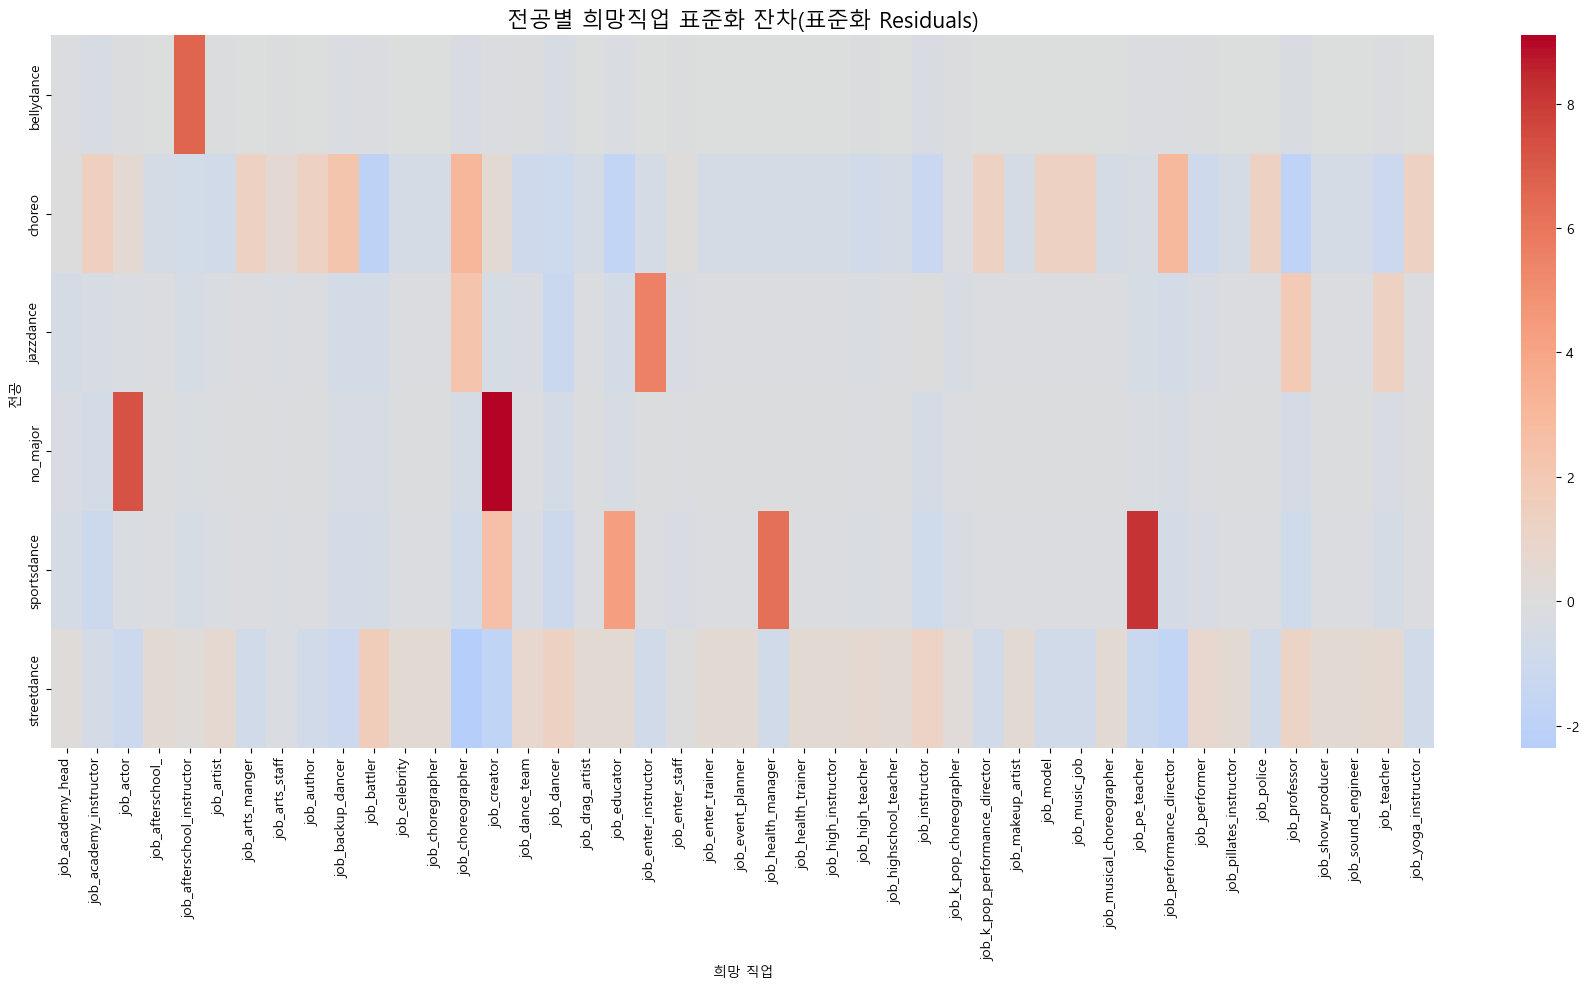


=== 유의미한 차이를 보이는 전공 × 직업 ===
              job_actor  job_afterschool_instructor  job_backup_dancer  \
major_detail                                                             
bellydance          NaN                    6.667092                NaN   
choreo              NaN                         NaN           2.238007   
jazzdance           NaN                         NaN                NaN   
no_major       7.223927                         NaN                NaN   
sportsdance         NaN                         NaN                NaN   
streetdance         NaN                         NaN                NaN   

              job_choreographer  job_creator  job_educator  \
major_detail                                                 
bellydance                  NaN          NaN           NaN   
choreo                 3.127979          NaN           NaN   
jazzdance              2.303903          NaN           NaN   
no_major                    NaN     9.094659           NaN   
sport

In [62]:
# -------------------------
# 전공 × 희망직업 잔차 분석
# -------------------------
from scipy.stats import chi2_contingency
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 직업 컬럼
job_cols = [c for c in df_raw_major.columns if c.startswith("job_")]

# 교차표(빈도)
contingency = df_raw_major.groupby("major_detail")[job_cols].sum()

# 카이제곱 분석
chi2, p, dof, expected = chi2_contingency(contingency)

# 표준화 잔차 계산
standardized_residuals = (contingency - expected) / np.sqrt(expected)

# -------------------------
# 시각화 (heatmap)
# -------------------------
plt.figure(figsize=(18,10))
sns.heatmap(standardized_residuals, annot=False, cmap="coolwarm", center=0)
plt.title("전공별 희망직업 표준화 잔차(표준화 Residuals)", fontsize=16)
plt.xlabel("희망 직업")
plt.ylabel("전공")
plt.tight_layout()
plt.show()

# -------------------------
# 잔차 상위/하위 값만 보여주기
# -------------------------
resid_df = standardized_residuals.copy()

# 절대값 기준으로 큰 차이만 추출
sig_resid = resid_df[(np.abs(resid_df) > 2)]  # |잔차|>2 = 유의미한 차이

print("\n=== 유의미한 차이를 보이는 전공 × 직업 ===")
print(sig_resid.dropna(how='all', axis=0).dropna(how='all', axis=1))


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_22884\975047729.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top5_jobs.values, y=top5_jobs.index, palette="coolwarm")


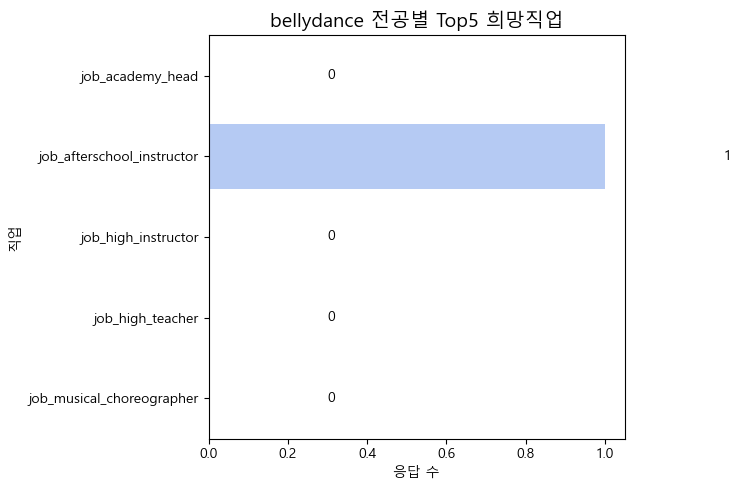

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_22884\975047729.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top5_jobs.values, y=top5_jobs.index, palette="coolwarm")


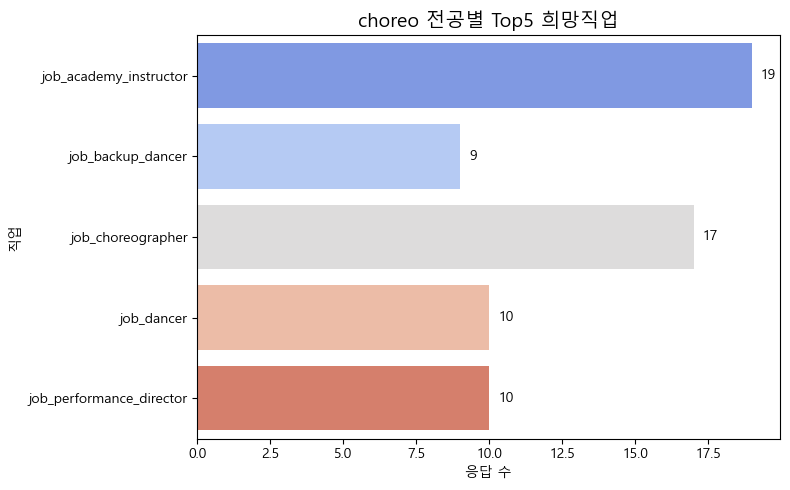

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_22884\975047729.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top5_jobs.values, y=top5_jobs.index, palette="coolwarm")


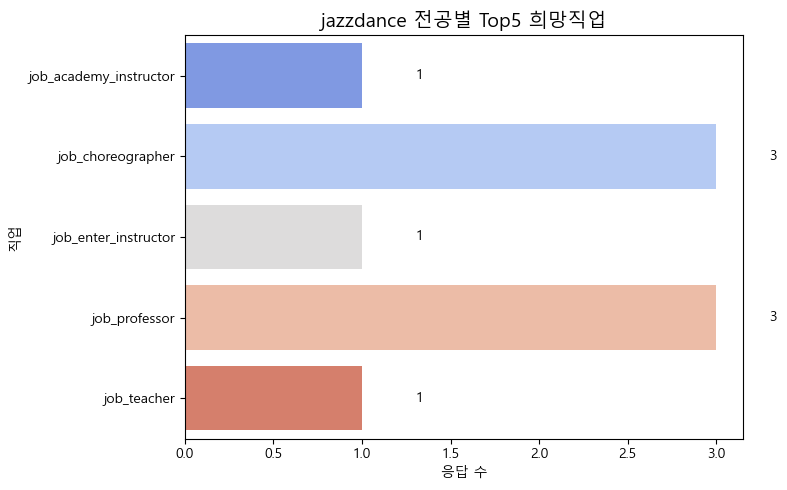

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_22884\975047729.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top5_jobs.values, y=top5_jobs.index, palette="coolwarm")


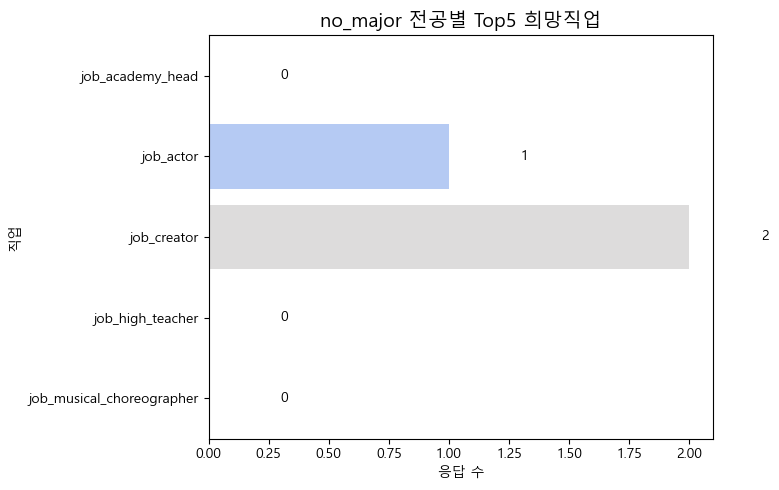

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_22884\975047729.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top5_jobs.values, y=top5_jobs.index, palette="coolwarm")


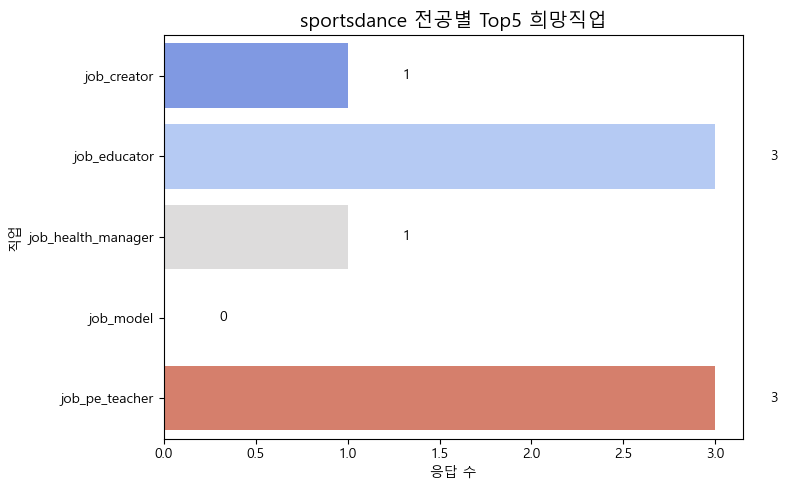

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_22884\975047729.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top5_jobs.values, y=top5_jobs.index, palette="coolwarm")


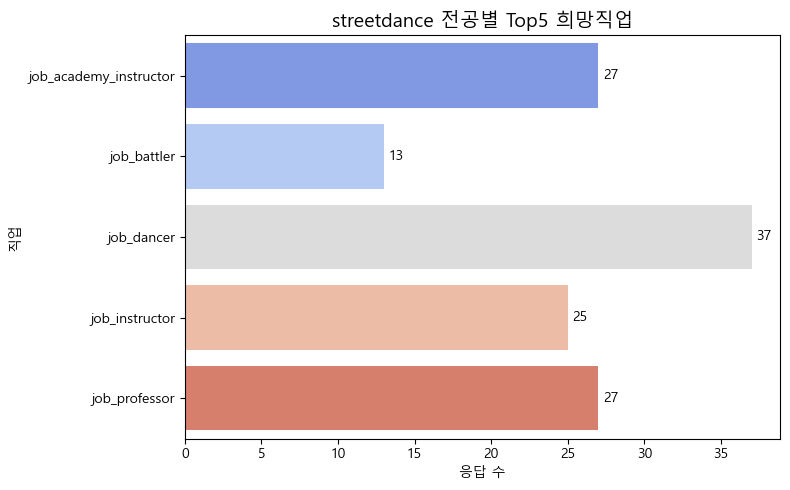

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 깨짐 방지
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# -------------------------
# 전공별 Top5 희망직업 Bar Plot
# -------------------------
for major in top5_by_major.index:
    top5_jobs = top5_by_major.loc[major]
    
    # 빈도 0 제외 (혹시 NaN인 경우)
    top5_jobs = top5_jobs.dropna()
    
    plt.figure(figsize=(8,5))
    sns.barplot(x=top5_jobs.values, y=top5_jobs.index, palette="coolwarm")
    
    # 막대 옆에 응답 수 표시
    for i, v in enumerate(top5_jobs.values):
        plt.text(v + 0.3, i, str(int(v)), va='center', fontsize=10)
    
    plt.title(f"{major} 전공별 Top5 희망직업", fontsize=14)
    plt.xlabel("응답 수")
    plt.ylabel("직업")
    plt.tight_layout()
    plt.show()


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_22884\2538418443.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=major_counts.index, x=major_counts.values, palette="viridis")


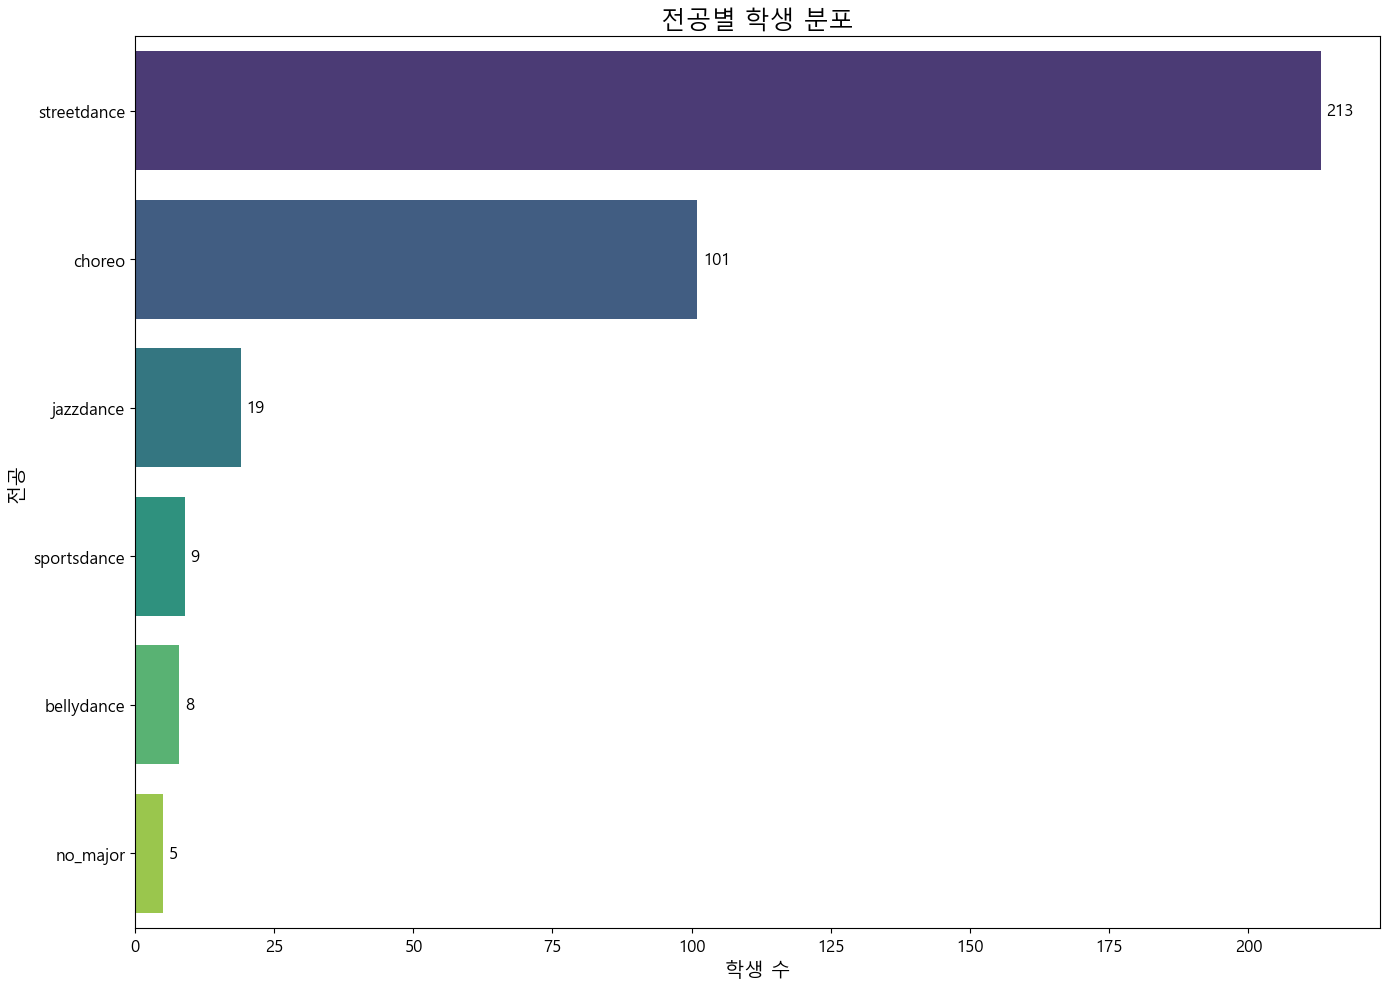

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

# 전공 카운트
major_counts = df_raw_major['major_detail'].value_counts()

plt.figure(figsize=(14, 10))  # 🔥 크기 넉넉히 확대
sns.barplot(y=major_counts.index, x=major_counts.values, palette="viridis")

# 막대 옆 숫자 표시
for i, v in enumerate(major_counts.values):
    plt.text(v + 1, i, str(v), va='center', fontsize=12)

plt.title("전공별 학생 분포", fontsize=18)
plt.xlabel("학생 수", fontsize=14)
plt.ylabel("전공", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()



<Figure size 1800x1000 with 0 Axes>

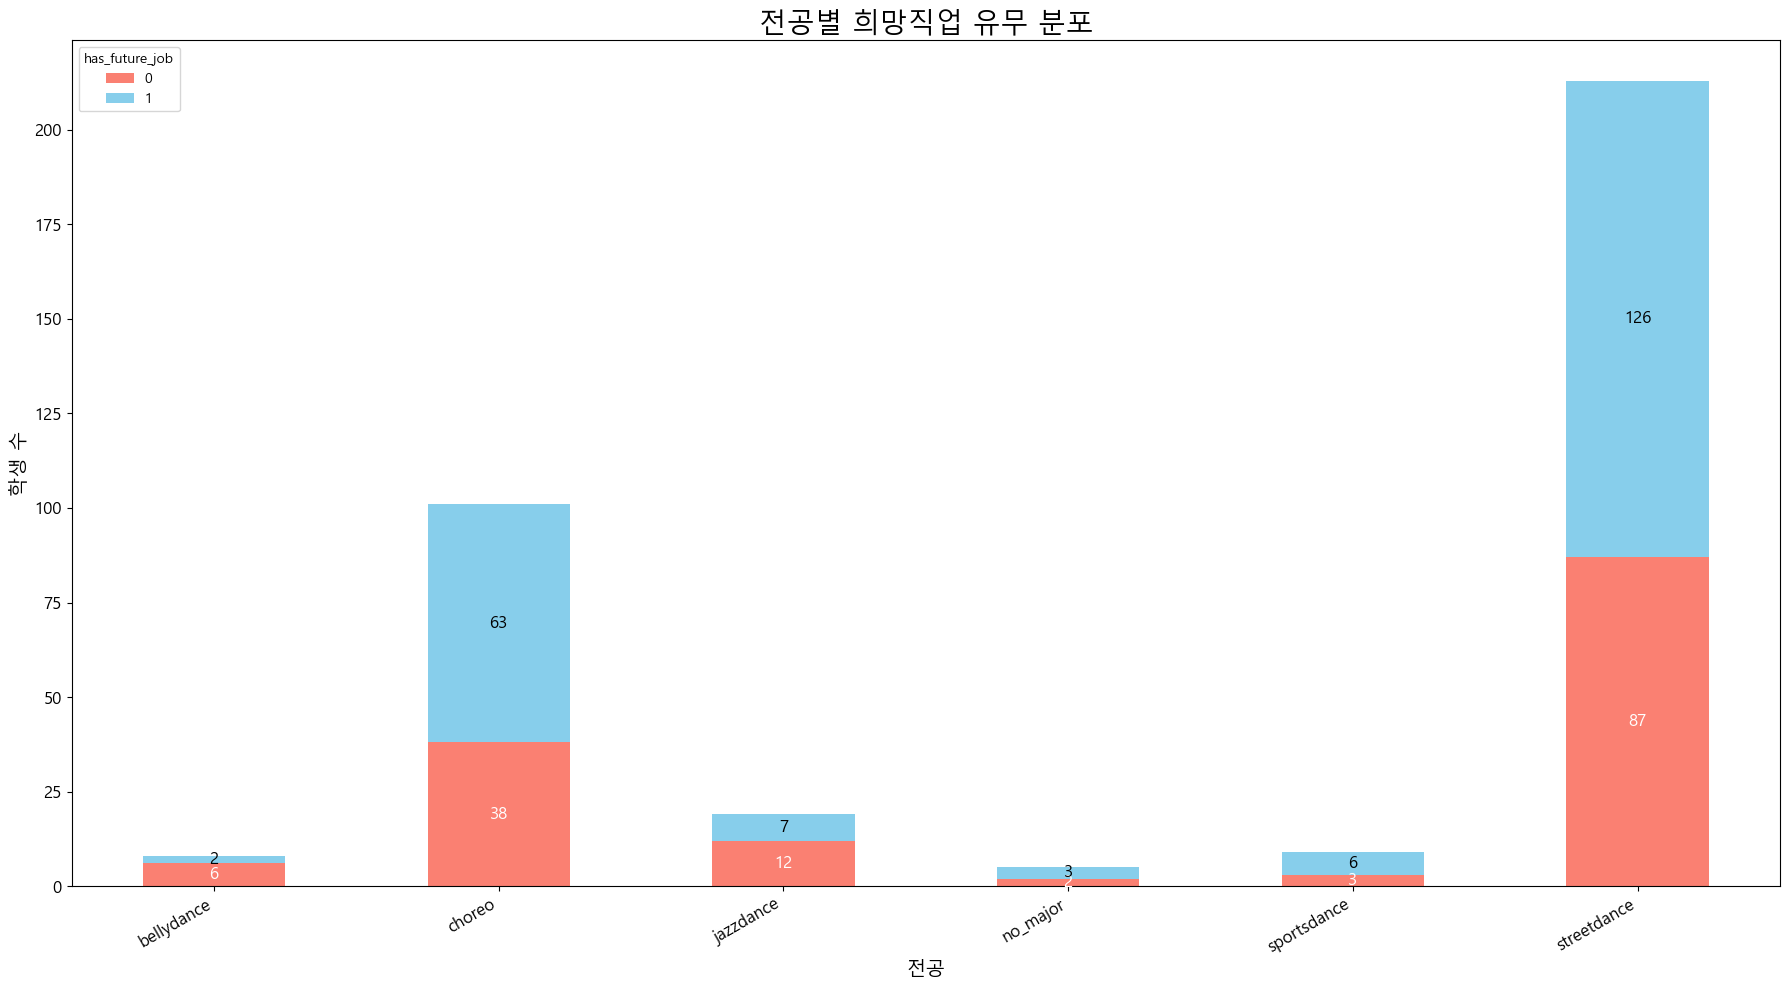

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 깨짐 방지
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# -------------------------
# 전공별 has_future_job 분포
# -------------------------
has_job_counts = df_raw_major.groupby('major_detail')['has_future_job'].value_counts().unstack(fill_value=0)

# 🔥 그래프 크게 키움 (중요)
plt.figure(figsize=(18, 10))

# Stacked bar 사용
ax = has_job_counts.plot(kind='bar', stacked=True, color=['salmon','skyblue'], figsize=(18,10))

# -------------------------
# 막대 옆 숫자 표시
# -------------------------
for i, row in enumerate(has_job_counts.values):
    # 없음
    ax.text(i, row[0]/2, str(int(row[0])),
            ha='center', va='center', color='white', fontsize=12)
    # 있음
    ax.text(i, row[0] + row[1]/2, str(int(row[1])),
            ha='center', va='center', color='black', fontsize=12)

# -------------------------
# 시각적 개선 (글자 깨짐/겹침 방지)
# -------------------------
plt.title("전공별 희망직업 유무 분포", fontsize=20)
plt.ylabel("학생 수", fontsize=14)
plt.xlabel("전공", fontsize=14)

plt.xticks(rotation=30, ha='right', fontsize=12)
plt.yticks(fontsize=12)

plt.margins(x=0.01)        # 막대가 너무 붙지 않도록
plt.tight_layout()
plt.show()


In [66]:
import pandas as pd
from scipy.stats import chi2_contingency

# 전공별 × 희망직업유무 교차표 (빈도표)
contingency = pd.crosstab(df_raw_major["major_detail"], df_raw_major["has_future_job"])

print("📌 교차표:")
print(contingency)

# 카이제곱 독립성 검정
chi2, p, dof, expected = chi2_contingency(contingency)

print("\n📊 카이제곱 검정 결과")
print(f"Chi-square 통계량: {chi2:.4f}")
print(f"p-value: {p:.6f}")
print(f"자유도: {dof}")
print("\n기대빈도표:")
print(pd.DataFrame(expected, 
                   index=contingency.index, 
                   columns=contingency.columns))


📌 교차표:
has_future_job   0    1
major_detail           
bellydance       6    2
choreo          38   63
jazzdance       12    7
no_major         2    3
sportsdance      3    6
streetdance     87  126

📊 카이제곱 검정 결과
Chi-square 통계량: 8.2675
p-value: 0.142097
자유도: 5

기대빈도표:
has_future_job          0           1
major_detail                         
bellydance       3.335211    4.664789
choreo          42.107042   58.892958
jazzdance        7.921127   11.078873
no_major         2.084507    2.915493
sportsdance      3.752113    5.247887
streetdance     88.800000  124.200000


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_22884\2907973273.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=job_total_counts.values, y=job_total_counts.index, palette="viridis")


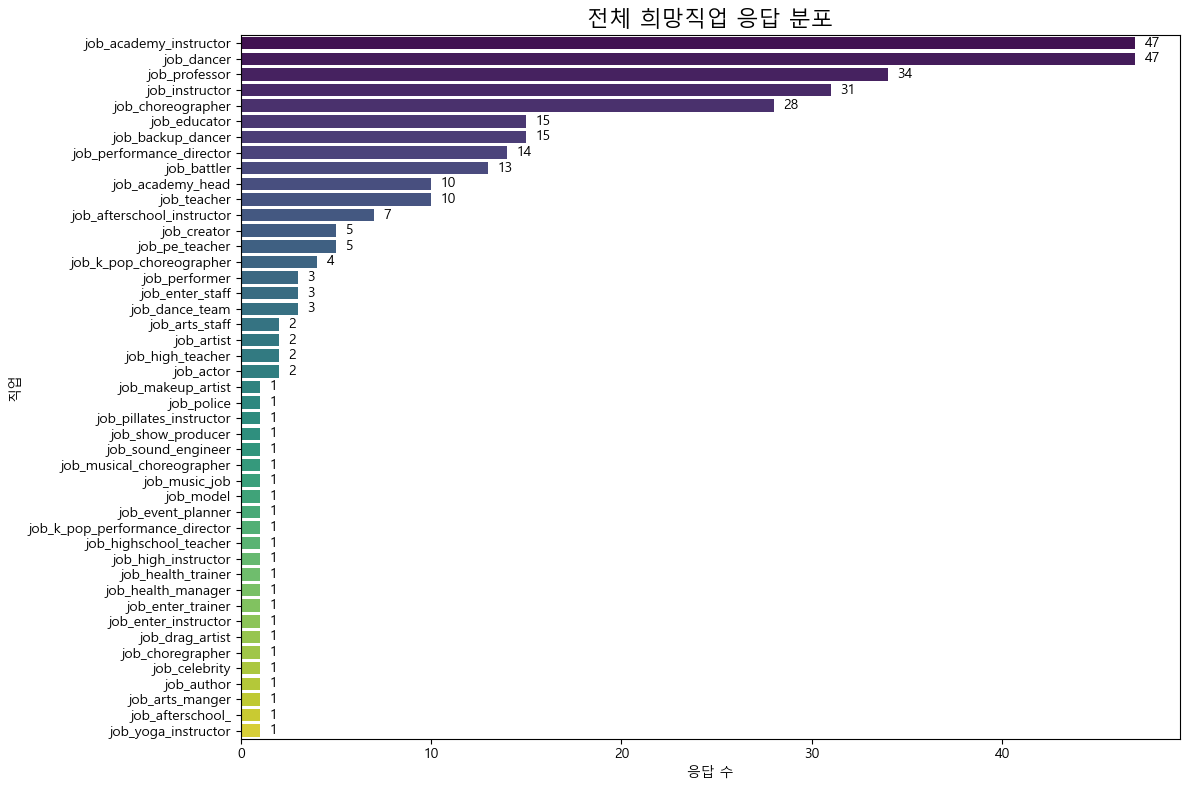

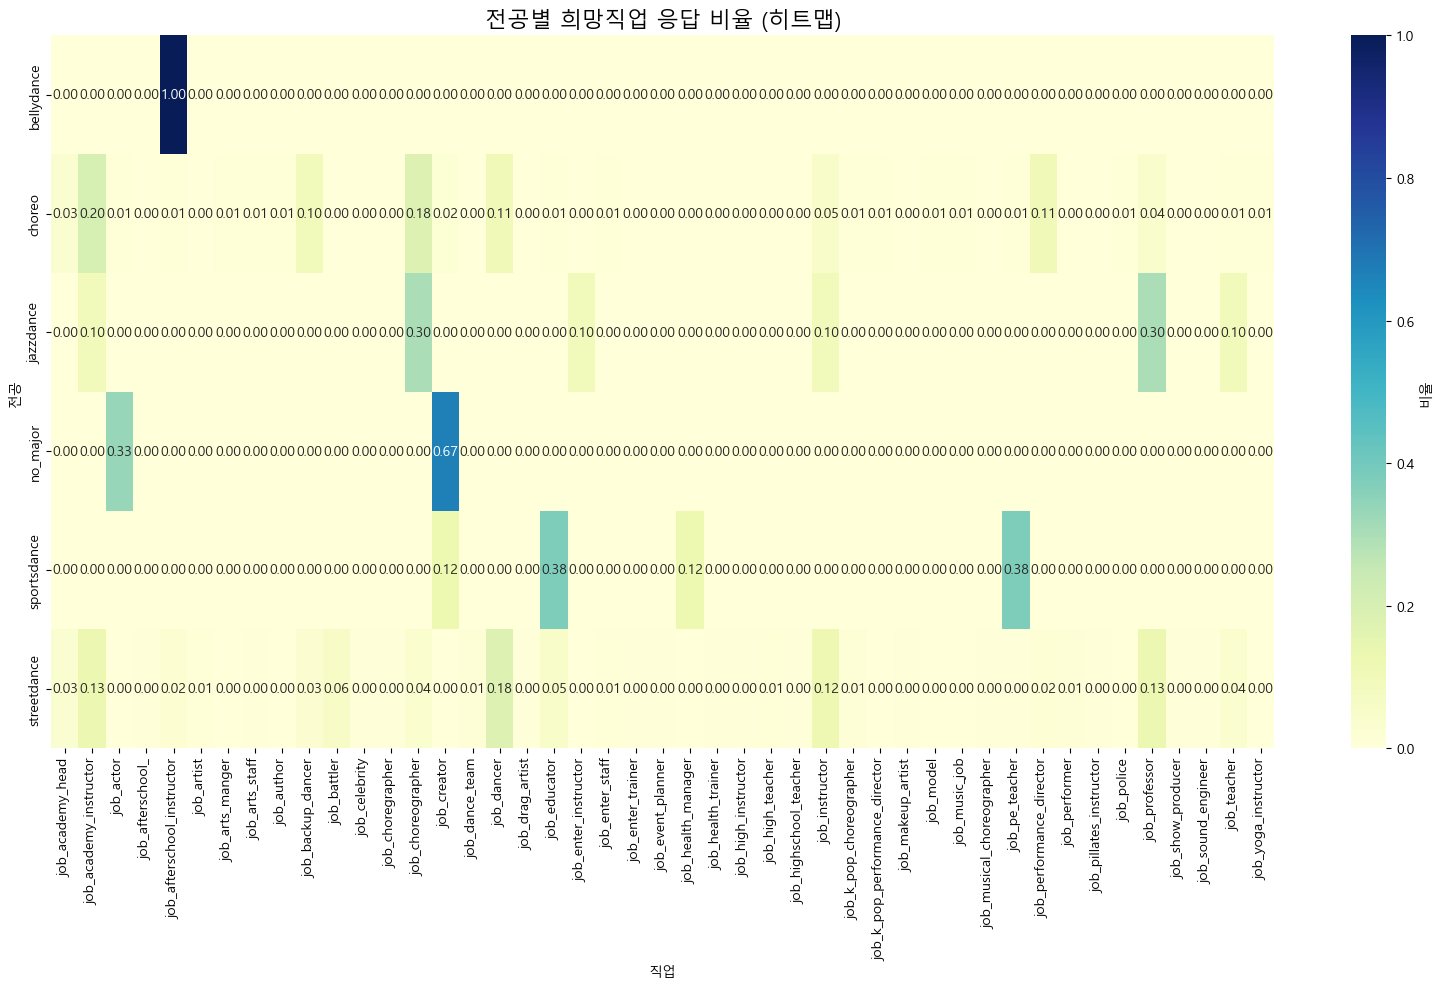

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_22884\2907973273.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top5_jobs.values, y=top5_jobs.index, palette="coolwarm")


ValueError: cannot convert float NaN to integer

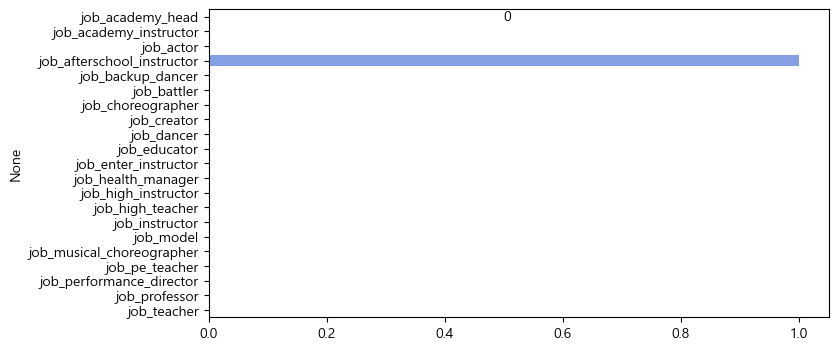

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 깨짐 방지
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# -------------------------
# 1) 전체 희망직업 응답 분포 Barplot (숫자 표시)
# -------------------------
plt.figure(figsize=(12,8))
sns.barplot(x=job_total_counts.values, y=job_total_counts.index, palette="viridis")

# 막대 옆 숫자 표시
for i, v in enumerate(job_total_counts.values):
    plt.text(v + 0.5, i, str(int(v)), va='center')

plt.title("전체 희망직업 응답 분포", fontsize=16)
plt.xlabel("응답 수")
plt.ylabel("직업")
plt.tight_layout()
plt.show()

# -------------------------
# 2) 전공별 희망직업 히트맵
# -------------------------
job_by_major_ratio = job_by_major.div(job_by_major.sum(axis=1), axis=0)

plt.figure(figsize=(16,10))
sns.heatmap(job_by_major_ratio, annot=True, fmt=".2f", cmap="YlGnBu", cbar_kws={'label':'비율'})
plt.title("전공별 희망직업 응답 비율 (히트맵)", fontsize=16)
plt.ylabel("전공")
plt.xlabel("직업")
plt.tight_layout()
plt.show()

# -------------------------
# 3) 전공별 Top5 희망직업 Barplot (숫자 표시)
# -------------------------
for major in top5_by_major.index:
    top5_jobs = top5_by_major.loc[major]
    plt.figure(figsize=(8,4))
    sns.barplot(x=top5_jobs.values, y=top5_jobs.index, palette="coolwarm")
    
    # 막대 옆 숫자 표시
    for i, v in enumerate(top5_jobs.values):
        plt.text(v + 0.5, i, str(int(v)), va='center')
    
    plt.title(f"{major} 전공별 Top5 희망직업", fontsize=14)
    plt.xlabel("응답 수")
    plt.ylabel("직업")
    plt.tight_layout()
    plt.show()


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_22884\1139951682.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=major_counts.index, x=major_counts.values, palette="viridis")


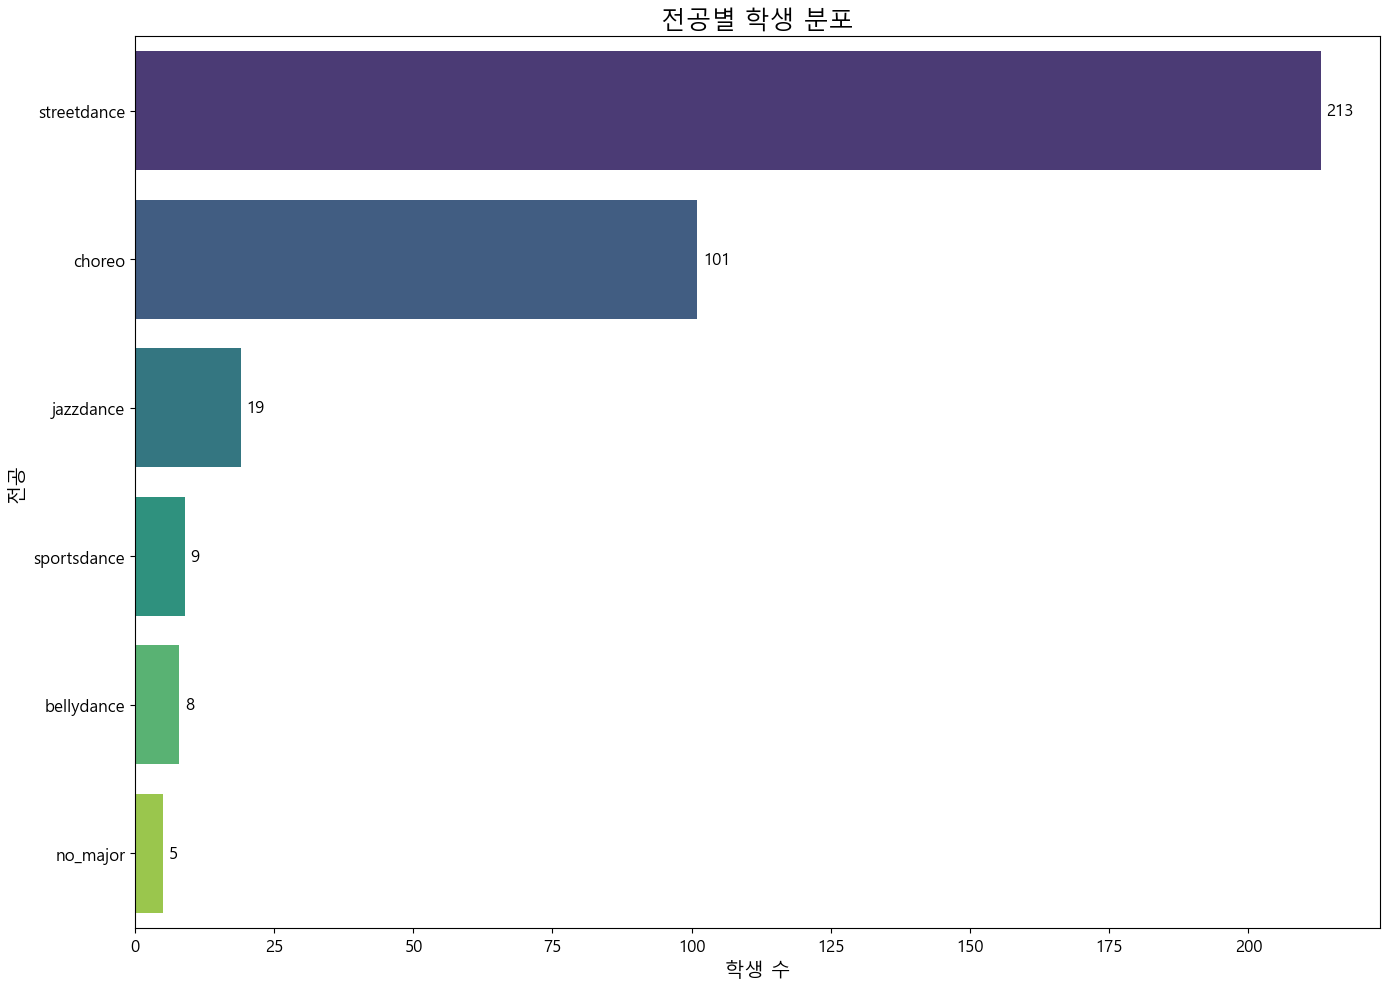

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

# 전공 카운트
major_counts = df_raw_major['major_detail'].value_counts()

plt.figure(figsize=(14, 10))  # 🔥 크기 넉넉히 확대
sns.barplot(y=major_counts.index, x=major_counts.values, palette="viridis")

# 막대 옆 숫자 표시
for i, v in enumerate(major_counts.values):
    plt.text(v + 1, i, str(v), va='center', fontsize=12)

plt.title("전공별 학생 분포", fontsize=18)
plt.xlabel("학생 수", fontsize=14)
plt.ylabel("전공", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_22884\1534883632.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=job_total_counts.values, y=job_total_counts.index, palette="viridis")


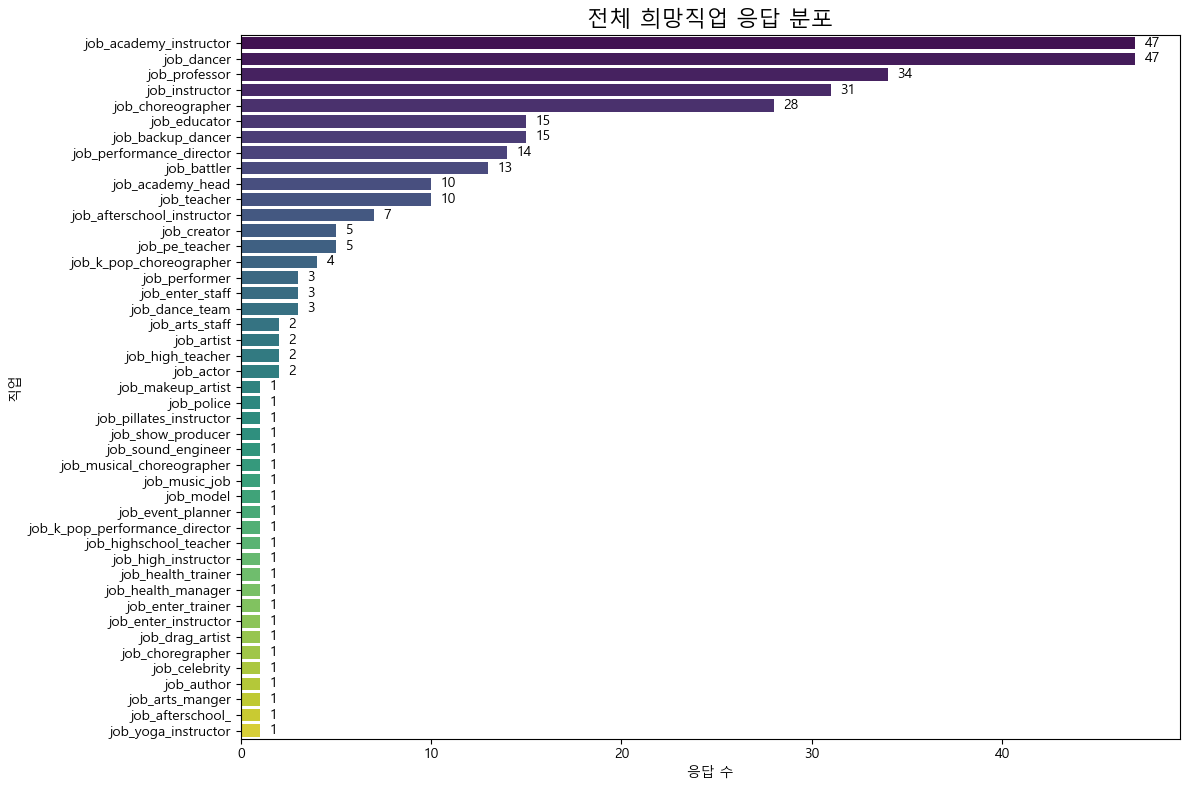

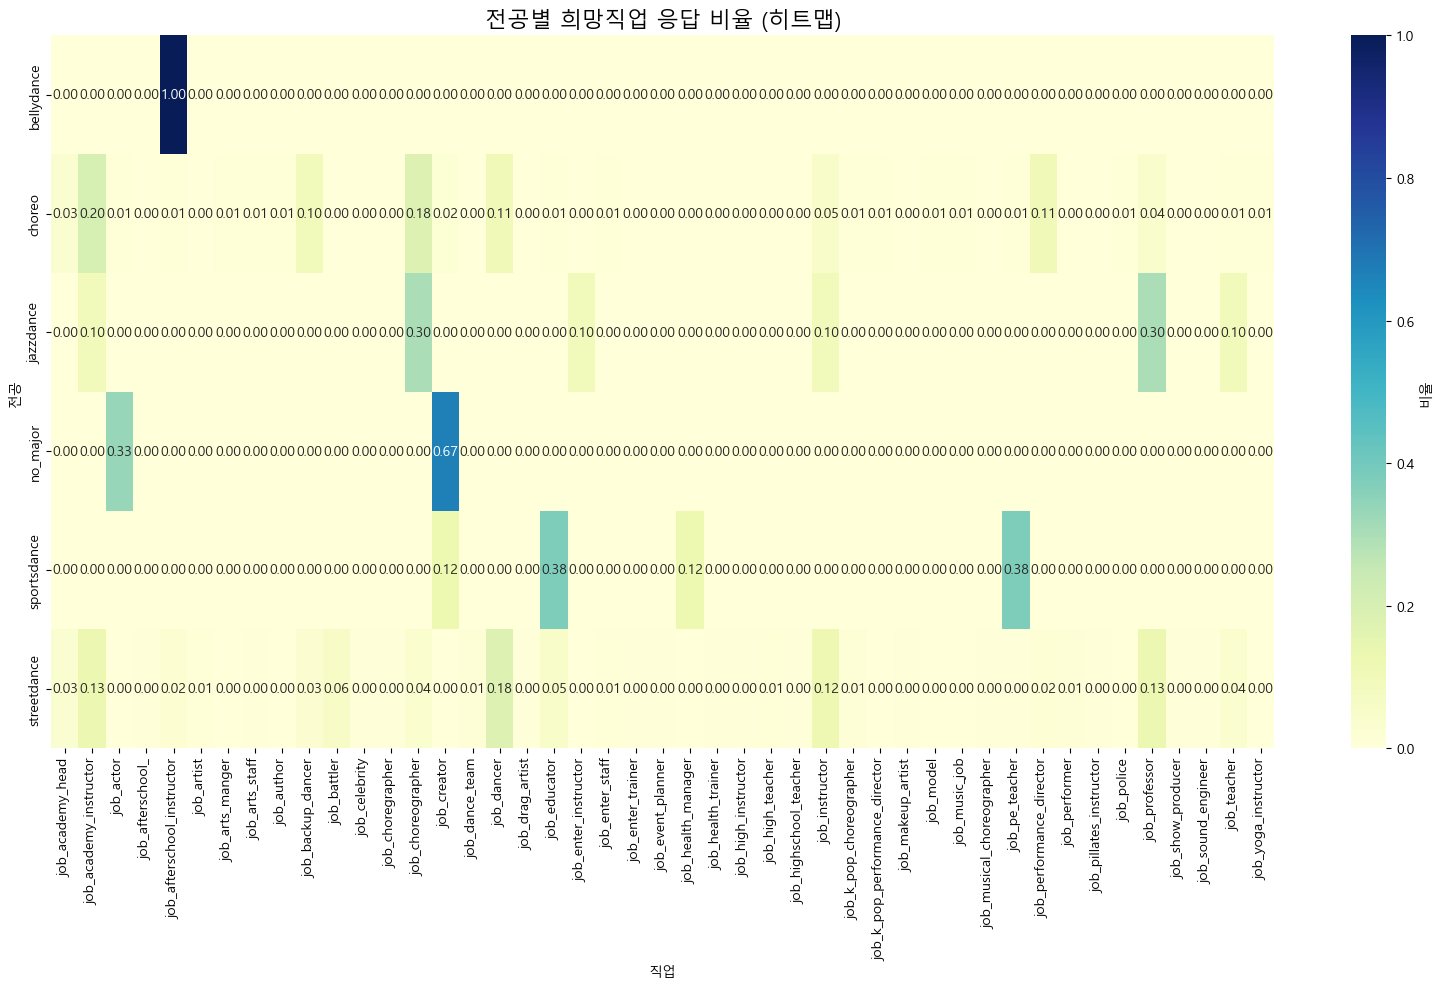

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_22884\1534883632.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top5_jobs.values, y=top5_jobs.index, palette="coolwarm")


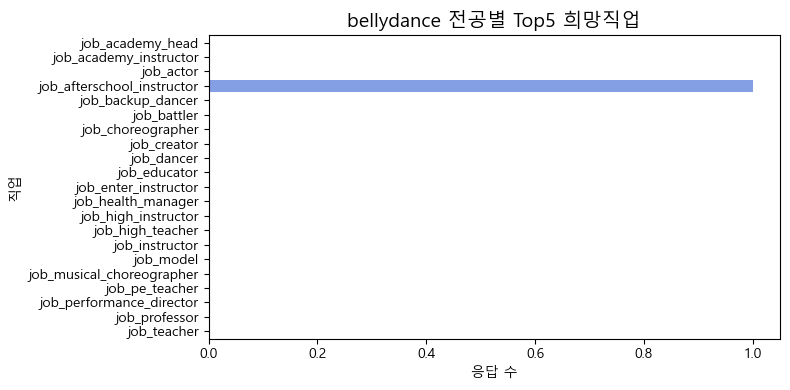

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_22884\1534883632.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top5_jobs.values, y=top5_jobs.index, palette="coolwarm")


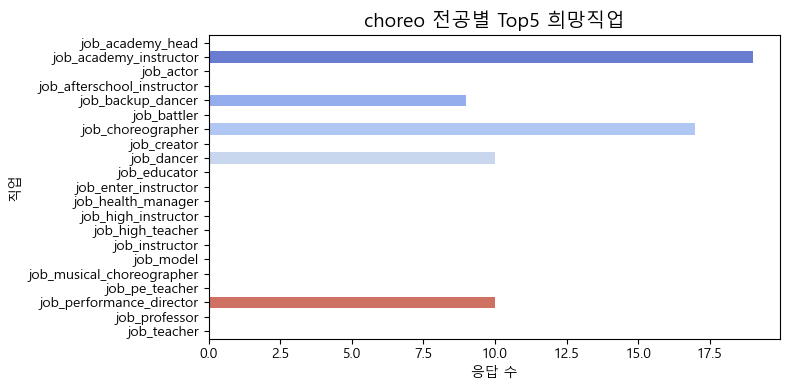

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_22884\1534883632.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top5_jobs.values, y=top5_jobs.index, palette="coolwarm")


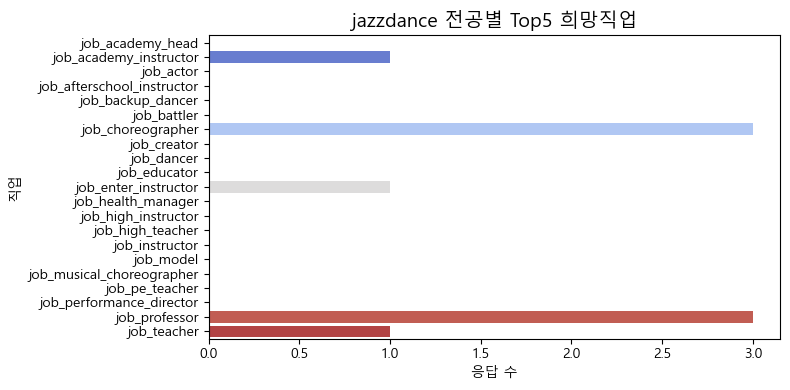

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_22884\1534883632.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top5_jobs.values, y=top5_jobs.index, palette="coolwarm")


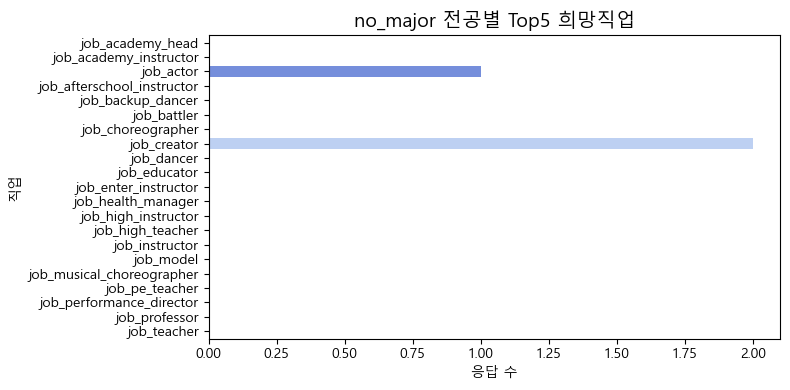

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_22884\1534883632.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top5_jobs.values, y=top5_jobs.index, palette="coolwarm")


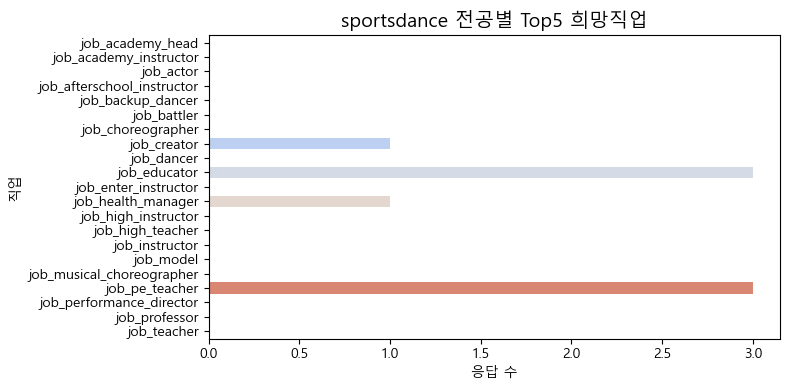

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_22884\1534883632.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top5_jobs.values, y=top5_jobs.index, palette="coolwarm")


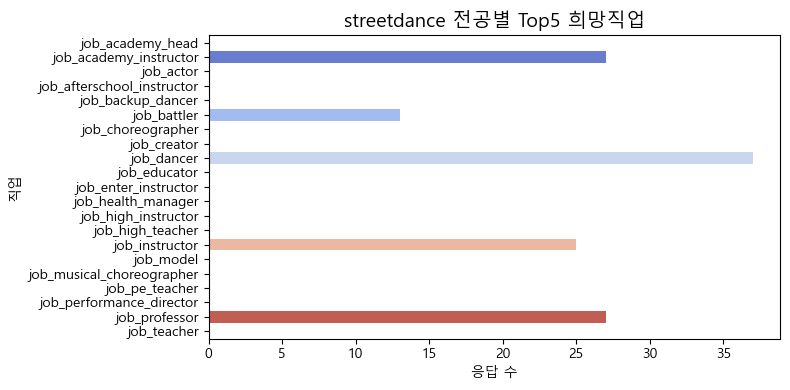

In [29]:
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

# -------------------------
# 1) 한글 폰트 설정 (Windows)
# -------------------------
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows 한글 폰트
plt.rcParams['axes.unicode_minus'] = False    # 마이너스 기호 깨짐 방지


import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------
# 1)희망직업 응답 분포 Barplot (숫자 표시)
# -------------------------
plt.figure(figsize=(12,8))
sns.barplot(x=job_total_counts.values, y=job_total_counts.index, palette="viridis")

# 막대 옆에 숫자 표시
for i, v in enumerate(job_total_counts.values):
    plt.text(v + 0.5, i, str(int(v)), va='center')  # va='center' : y축 중앙 맞춤

plt.title("전체 희망직업 응답 분포", fontsize=16)
plt.xlabel("응답 수")
plt.ylabel("직업")
plt.tight_layout()
plt.show()
# -------------------------
# 2) 전공별 희망직업 히트맵
# -------------------------
# 전공별 합계 / 비율 변환 (0~1)
job_by_major_ratio = job_by_major.div(job_by_major.sum(axis=1), axis=0)

plt.figure(figsize=(16,10))
sns.heatmap(job_by_major_ratio, annot=True, fmt=".2f", cmap="YlGnBu", cbar_kws={'label':'비율'})
plt.title("전공별 희망직업 응답 비율 (히트맵)", fontsize=16)
plt.ylabel("전공")
plt.xlabel("직업")
plt.tight_layout()
plt.show()

# -------------------------
# 3) 전공별 Top5 희망직업 강조 Barplot
# -------------------------
for major in top5_by_major.index:
    top5_jobs = top5_by_major.loc[major]
    plt.figure(figsize=(8,4))
    sns.barplot(x=top5_jobs.values, y=top5_jobs.index, palette="coolwarm")
    plt.title(f"{major} 전공별 Top5 희망직업", fontsize=14)
    plt.xlabel("응답 수")
    plt.ylabel("직업")
    plt.tight_layout()
    plt.show()


In [5]:
import scipy.stats as stats

chi2, p, dof, expected = stats.chi2_contingency(job_table)
print("Chi-square:", chi2)
print("p-value:", p)


Chi-square: 8.267479776148809
p-value: 0.14209738051136944


In [8]:
import re
from sklearn.preprocessing import MultiLabelBinarizer

# -----------------------------------------
# 1) future_job_desc → 리스트로 변환
# -----------------------------------------
def clean_job_list(x):
    if pd.isna(x):
        return []
    # 콤마, 공백 기준 split
    items = re.split(r'[,\s]+', x.strip())
    # 빈 값 제거
    return [item for item in items if item != ""]

df['future_job_list'] = df['future_job_desc'].apply(clean_job_list)

# -----------------------------------------
# 2) MultiLabelBinarizer 적용
# -----------------------------------------
mlb = MultiLabelBinarizer()
job_dummies = pd.DataFrame(
    mlb.fit_transform(df['future_job_list']),
    columns=[f"job_{job}" for job in mlb.classes_],
    index=df.index
)

# -----------------------------------------
# 3) merge
# -----------------------------------------
df = pd.concat([df, job_dummies], axis=1)

print("생성된 job_* 컬럼:", job_dummies.columns.tolist())


생성된 job_* 컬럼: ['job_academy_head', 'job_academy_instructor', 'job_actor', 'job_afterschool_', 'job_afterschool_instructor', 'job_artist', 'job_arts_manger', 'job_arts_staff', 'job_author', 'job_backup_dancer', 'job_battler', 'job_celebrity', 'job_choregrapher', 'job_choreographer', 'job_creator', 'job_dance_team', 'job_dancer', 'job_drag_artist', 'job_educator', 'job_enter_instructor', 'job_enter_staff', 'job_enter_trainer', 'job_event_planner', 'job_health_manager', 'job_health_trainer', 'job_high_instructor', 'job_high_teacher', 'job_highschool_teacher', 'job_instructor', 'job_k_pop_choreographer', 'job_k_pop_performance_director', 'job_makeup_artist', 'job_model', 'job_music_job', 'job_musical_choreographer', 'job_pe_teacher', 'job_performance_director', 'job_performer', 'job_pillates_instructor', 'job_police', 'job_professor', 'job_show_producer', 'job_sound_engineer', 'job_teacher', 'job_yoga_instructor']


In [9]:
# job_* 컬럼만 추출
job_cols = [col for col in df.columns if col.startswith("job_")]

# 전체 빈도
job_total_counts = df[job_cols].sum().sort_values(ascending=False)

print(job_total_counts)


job_region_seoul                  233.0
job_test                          159.0
job_prep                           93.0
job_info                           89.0
job_region_wherever                66.0
job_academy_instructor             47.0
job_dancer                         47.0
job_fair                           38.0
job_professor                      34.0
job_region_yeongnam                32.0
job_instructor                     31.0
job_choreographer                  28.0
job_educator                       15.0
job_backup_dancer                  15.0
job_performance_director           14.0
job_battler                        13.0
job_teacher                        10.0
job_academy_head                   10.0
job_region_chungcheong              9.0
job_afterschool_instructor          7.0
job_region_honam                    6.0
job_region_abroad                   6.0
job_pe_teacher                      5.0
job_creator                         5.0
job_k_pop_choreographer             4.0


In [51]:
from scipy.stats import chi2_contingency

# job_ 로 시작하는 모든 희망직업 컬럼 목록
job_cols = [col for col in df.columns if col.startswith("job_")]

# 전공별 직업 빈도표 (각 직업이 선택된 횟수 합)
contingency = df.groupby("major_detail_raw")[job_cols].sum()

print("📌 전공 × 직업 교차표:")
print(contingency)

# 카이제곱 검정
chi2, p, dof, expected = chi2_contingency(contingency)

print("\n📊 카이제곱 결과:")
print(f"Chi2 = {chi2:.4f}")
print(f"p-value = {p:.6f}")
print(f"df = {dof}")


📌 전공 × 직업 교차표:
                  job_test  job_prep  job_info  job_fair  job_region_abroad  \
major_detail_raw                                                              
bellydance               3         1         3         2                0.0   
choreo                  49        24        19         5                2.0   
jazzdance                7         4         3         1                0.0   
no_major                 0         1         1         0                0.0   
sportsdance              3         2         2         1                1.0   
streetdance             97        61        61        29                3.0   

                  job_region_chungcheong  job_region_gangwon  \
major_detail_raw                                               
bellydance                           1.0                 0.0   
choreo                               3.0                 1.0   
jazzdance                            1.0                 0.0   
no_major                        